In [1]:
# ============================================================
# THERMAL WIND PREDICTION PROJECT
# BUOY DATA PREPROCESSING
# ============================================================

# -------------------------
# IMPORTS
# -------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Configuración visual
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ============================================================
# PROJECT PATHS
# ============================================================

# Ajusta esta ruta a tu proyecto
PROJECT_ROOT = Path.cwd().parent

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"

# Crear carpetas si no existen
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

print("Project paths ready.")
print(f"RAW DATA: {RAW_DATA_PATH}")
print(f"PROCESSED DATA: {PROCESSED_DATA_PATH}")

Project paths ready.
RAW DATA: /Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/03_Especialitzacio/Project/thermal-wind-prediction/data/raw
PROCESSED DATA: /Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/03_Especialitzacio/Project/thermal-wind-prediction/data/processed


In [3]:
# ============================================================
# LOAD BUOY DATASET
# ============================================================

file_name = "Boya 2005-2025 - 25933_53782_1731_ALL_20050101120619_20251231120619.csv"

file_path = RAW_DATA_PATH / file_name

# Leer CSV ignorando primera línea
df = pd.read_csv(
    file_path,
    sep="\t",
    encoding="utf-8",
    skiprows=1,
    low_memory=False
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
display(df.head(10))

,Fecha (GMT),Altura Signif. del Oleaje (Hm0)(m),Altura signif. de cruce por cero (H1/3)(m),Periodo Medio(s),Periodo Medio Tm02(s),Periodo de Pico(s),Altura Máxima del Oleaje(m),Periodo de la Ola Maxima(s),Canal de obtencion de los datos,"Direcc. Media de Proced.(0=N,90=E)","Direccion Media en el Pico Espectral(0=N,90=E)",Dispersión angular en toda la banda resuelta(grados),Dispersión angular en el pico de energía espectral(grados),Canal de obtencion de los datos.1,Temperatura del Agua(ºC),Canal de obtencion de los datos.2
0,2005 01 01 00,1.00,0.90,4.78,4.37,6.65,1.37,6.66,1.0,105.0,96.0,-9999.9,34.0,1.0,14.4,3.0
1,2005 01 01 01,0.93,0.88,4.83,4.49,7.13,1.26,7.47,1.0,101.0,92.0,-9999.9,24.0,1.0,14.4,3.0
2,2005 01 01 02,0.96,0.86,4.95,4.65,6.45,1.90,6.06,1.0,100.0,88.0,-9999.9,36.0,1.0,14.4,3.0
3,2005 01 01 03,0.81,0.74,4.99,4.56,6.90,1.18,7.12,1.0,103.0,97.0,-9999.9,37.0,1.0,14.4,3.0
4,2005 01 01 04,0.74,0.67,4.60,4.24,6.65,1.17,6.09,1.0,106.0,100.0,-9999.9,45.0,1.0,14.3,3.0
5,2005 01 01 05,0.76,0.66,4.41,4.04,6.24,1.32,6.12,1.0,107.0,99.0,-9999.9,35.0,1.0,14.4,3.0
6,2005 01 01 06,0.69,0.61,4.77,4.39,6.65,1.03,6.54,1.0,111.0,116.0,-9999.9,38.0,1.0,14.4,3.0
7,2005 01 01 07,0.57,0.54,4.83,4.12,7.13,0.99,5.09,1.0,118.0,123.0,-9999.9,52.0,1.0,14.3,3.0
8,2005 01 01 08,0.57,0.50,4.58,4.10,6.86,0.91,5.96,1.0,123.0,110.0,-9999.9,38.0,1.0,14.4,3.0
9,2005 01 01 09,0.54,0.50,5.21,4.58,7.42,0.86,6.99,1.0,118.0,134.0,-9999.9,30.0,1.0,14.4,3.0


In [5]:
# ============================================================
# INITIAL INSPECTION
# ============================================================

print("\nDATAFRAME SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nFIRST ROWS")
display(df.head())

print("\nINFO")
df.info()


DATAFRAME SHAPE
(162805, 16)

COLUMN NAMES
['Fecha (GMT)', 'Altura Signif. del Oleaje (Hm0)(m)', 'Altura signif. de cruce por cero (H1/3)(m)', 'Periodo Medio(s)', 'Periodo Medio Tm02(s)', 'Periodo de Pico(s)', 'Altura Máxima del Oleaje(m)', 'Periodo de la Ola Maxima(s)', 'Canal de obtencion de los datos', 'Direcc. Media de Proced.(0=N,90=E)', 'Direccion Media en el Pico Espectral(0=N,90=E)', 'Dispersión angular en toda la banda resuelta(grados)', 'Dispersión angular en el pico de energía espectral(grados)', 'Canal de obtencion de los datos.1', 'Temperatura del Agua(ºC)', 'Canal de obtencion de los datos.2']

FIRST ROWS


,Fecha (GMT),Altura Signif. del Oleaje (Hm0)(m),Altura signif. de cruce por cero (H1/3)(m),Periodo Medio(s),Periodo Medio Tm02(s),Periodo de Pico(s),Altura Máxima del Oleaje(m),Periodo de la Ola Maxima(s),Canal de obtencion de los datos,"Direcc. Media de Proced.(0=N,90=E)","Direccion Media en el Pico Espectral(0=N,90=E)",Dispersión angular en toda la banda resuelta(grados),Dispersión angular en el pico de energía espectral(grados),Canal de obtencion de los datos.1,Temperatura del Agua(ºC),Canal de obtencion de los datos.2
0,2005 01 01 00,1.00,0.90,4.78,4.37,6.65,1.37,6.66,1.0,105.0,96.0,-9999.9,34.0,1.0,14.4,3.0
1,2005 01 01 01,0.93,0.88,4.83,4.49,7.13,1.26,7.47,1.0,101.0,92.0,-9999.9,24.0,1.0,14.4,3.0
2,2005 01 01 02,0.96,0.86,4.95,4.65,6.45,1.90,6.06,1.0,100.0,88.0,-9999.9,36.0,1.0,14.4,3.0
3,2005 01 01 03,0.81,0.74,4.99,4.56,6.90,1.18,7.12,1.0,103.0,97.0,-9999.9,37.0,1.0,14.4,3.0
4,2005 01 01 04,0.74,0.67,4.60,4.24,6.65,1.17,6.09,1.0,106.0,100.0,-9999.9,45.0,1.0,14.3,3.0



INFO
<class 'pandas.DataFrame'>
RangeIndex: 162805 entries, 0 to 162804
Data columns (total 16 columns):
 #   Column                                                      Non-Null Count   Dtype  
---  ------                                                      --------------   -----  
 0   Fecha (GMT)                                                 162805 non-null  str    
 1   Altura Signif. del Oleaje (Hm0)(m)                          162805 non-null  float64
 2   Altura signif. de cruce por cero (H1/3)(m)                  162805 non-null  float64
 3   Periodo Medio(s)                                            162805 non-null  float64
 4   Periodo Medio Tm02(s)                                       162805 non-null  float64
 5   Periodo de Pico(s)                                          162805 non-null  float64
 6   Altura Máxima del Oleaje(m)                                 162805 non-null  float64
 7   Periodo de la Ola Maxima(s)                                 162805 non-null  fl

In [6]:
# ============================================================
# CLEAN AND STANDARDIZE COLUMN NAMES
# ============================================================

df.columns = [

    col.strip()
    .lower()
    .replace(" ", "_")
    .replace(".", "")
    .replace("(", "")
    .replace(")", "")
    .replace("/", "_")
    .replace("º", "")
    .replace("=", "")
    .replace("-", "_")

    for col in df.columns
]

print(df.columns.tolist())

['fecha_gmt', 'altura_signif_del_oleaje_hm0m', 'altura_signif_de_cruce_por_cero_h1_3m', 'periodo_medios', 'periodo_medio_tm02s', 'periodo_de_picos', 'altura_máxima_del_oleajem', 'periodo_de_la_ola_maximas', 'canal_de_obtencion_de_los_datos', 'direcc_media_de_proced0n,90e', 'direccion_media_en_el_pico_espectral0n,90e', 'dispersión_angular_en_toda_la_banda_resueltagrados', 'dispersión_angular_en_el_pico_de_energía_espectralgrados', 'canal_de_obtencion_de_los_datos1', 'temperatura_del_aguac', 'canal_de_obtencion_de_los_datos2']


In [7]:
# ============================================================
# RENAME IMPORTANT COLUMNS
# ============================================================

df = df.rename(columns={

    'fecha_gmt': 'datetime',

    'altura_signif_del_oleaje_hm0m': 'wave_height',

    'periodo_medios': 'wave_period_mean',

    'periodo_medio_tm02s': 'wave_period_tm02',

    'periodo_de_picos': 'wave_peak_period',

    'direcc_media_de_proced0n90e': 'wave_direction',

    'temperatura_del_aguac': 'sst'

})

print("Columns renamed successfully.")

Columns renamed successfully.


In [8]:
# ============================================================
# CHECK FINAL COLUMN NAMES
# ============================================================

print(df.columns.tolist())

['datetime', 'wave_height', 'altura_signif_de_cruce_por_cero_h1_3m', 'wave_period_mean', 'wave_period_tm02', 'wave_peak_period', 'altura_máxima_del_oleajem', 'periodo_de_la_ola_maximas', 'canal_de_obtencion_de_los_datos', 'direcc_media_de_proced0n,90e', 'direccion_media_en_el_pico_espectral0n,90e', 'dispersión_angular_en_toda_la_banda_resueltagrados', 'dispersión_angular_en_el_pico_de_energía_espectralgrados', 'canal_de_obtencion_de_los_datos1', 'sst', 'canal_de_obtencion_de_los_datos2']


In [9]:
# ============================================================
# CONVERT INVALID VALUES TO NaN
# ============================================================

invalid_values = [

    -9999,
    -9999.0,
    -9999.9,
    -9999.99

]

df.replace(invalid_values, np.nan, inplace=True)

print("Invalid values converted to NaN.")

Invalid values converted to NaN.


In [10]:
# ============================================================
# CHECK MISSING VALUES
# ============================================================

missing_values = df.isna().sum().sort_values(ascending=False)

missing_percentage = (missing_values / len(df)) * 100

missing_report = pd.DataFrame({

    'missing_values': missing_values,
    'missing_percentage': missing_percentage

})

display(missing_report)

,missing_values,missing_percentage
dispersión_angular_en_toda_la_banda_resueltagrados,155921,95.771629
"direccion_media_en_el_pico_espectral0n,90e",9423,5.787906
dispersión_angular_en_el_pico_de_energía_espectralgrados,9423,5.787906
periodo_de_la_ola_maximas,8534,5.241854
sst,5881,3.612297
canal_de_obtencion_de_los_datos2,5112,3.139953
"direcc_media_de_proced0n,90e",2539,1.559534
wave_period_tm02,2052,1.260404
wave_height,1650,1.013482
altura_signif_de_cruce_por_cero_h1_3m,1650,1.013482


In [11]:
# ============================================================
# PARSE DATETIME
# ============================================================

df['datetime'] = pd.to_datetime(

    df['datetime'],
    format='%Y %m %d %H',
    errors='coerce'

)

print("Datetime parsed successfully.")

Datetime parsed successfully.


In [12]:
# ============================================================
# SET DATETIME INDEX
# ============================================================

df = df.set_index('datetime')

# Ordenar temporalmente
df = df.sort_index()

print("Datetime index configured.")

Datetime index configured.


In [13]:
# ============================================================
# REMOVE NON-USEFUL COLUMNS
# ============================================================

columns_to_drop = [

    'canal_de_obtencion_de_los_datos',
    'canal_de_obtencion_de_los_datos1',
    'canal_de_obtencion_de_los_datos2',
    'dispersión_angular_en_toda_la_banda_resueltagrados'

]

df = df.drop(columns=columns_to_drop)

print("Non-useful columns removed.")

Non-useful columns removed.


In [14]:
# ============================================================
# CHECK TEMPORAL CONTINUITY
# ============================================================

time_diff = df.index.to_series().diff()

print(time_diff.value_counts().head(10))

datetime
0 days 01:00:00    162496
0 days 02:00:00       223
0 days 03:00:00        27
0 days 04:00:00        10
0 days 05:00:00         6
0 days 07:00:00         4
0 days 12:00:00         4
0 days 06:00:00         4
0 days 08:00:00         3
0 days 11:00:00         2
Name: count, dtype: int64


In [15]:
# ============================================================
# CREATE COMPLETE HOURLY TIMELINE
# ============================================================

full_time_index = pd.date_range(

    start=df.index.min(),
    end=df.index.max(),
    freq='h'

)

df = df.reindex(full_time_index)

print("Full hourly timeline created.")

print(f"New shape: {df.shape}")

Full hourly timeline created.
New shape: (184080, 11)


In [16]:
# ============================================================
# CHECK NEW MISSING VALUES AFTER REINDEX
# ============================================================

missing_values = df.isna().sum().sort_values(ascending=False)

missing_percentage = (missing_values / len(df)) * 100

missing_report = pd.DataFrame({

    'missing_values': missing_values,
    'missing_percentage': missing_percentage

})

display(missing_report)

,missing_values,missing_percentage
"direccion_media_en_el_pico_espectral0n,90e",30698,16.676445
dispersión_angular_en_el_pico_de_energía_espectralgrados,30698,16.676445
periodo_de_la_ola_maximas,29809,16.193503
sst,27156,14.752282
"direcc_media_de_proced0n,90e",23814,12.936767
wave_period_tm02,23327,12.672208
wave_height,22925,12.453824
altura_signif_de_cruce_por_cero_h1_3m,22925,12.453824
wave_period_mean,22925,12.453824
wave_peak_period,22925,12.453824


In [17]:
# ============================================================
# ANALYZE SST GAP SIZES
# ============================================================

# Detectar NaNs SST
sst_nan = df['sst'].isna()

# Crear grupos consecutivos
groups = (sst_nan != sst_nan.shift()).cumsum()

# Contar tamaño de gaps
gap_sizes = sst_nan.groupby(groups).sum()

# Quedarnos solo gaps reales
gap_sizes = gap_sizes[gap_sizes > 0]

print(gap_sizes.describe())

print("\nTOP 20 BIGGEST GAPS")
display(gap_sizes.sort_values(ascending=False).head(20))

count     2357.000000
mean        11.521426
std        301.189897
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max      14275.000000
Name: sst, dtype: float64

TOP 20 BIGGEST GAPS


sst
600     14275
604      2878
356       590
3198      583
464       579
3274      447
134       438
3560      396
1626      290
3224      268
232       237
142       229
1276      122
3710      113
4686      108
1754       92
4642       87
3328       78
3070       72
476        71
Name: sst, dtype: int64

In [18]:
# ============================================================
# FIND LONGEST SST GAP
# ============================================================

# Serie booleana
sst_nan = df['sst'].isna()

# Grupos consecutivos
groups = (sst_nan != sst_nan.shift()).cumsum()

# Crear dataframe temporal
gap_df = pd.DataFrame({

    'is_nan': sst_nan,
    'group': groups

})

# Filtrar solo gaps
gap_info = gap_df[gap_df['is_nan']].groupby('group').apply(

    lambda x: pd.Series({

        'start': x.index.min(),
        'end': x.index.max(),
        'duration_hours': len(x)

    })

)

# Ordenar gaps más grandes
gap_info = gap_info.sort_values(

    by='duration_hours',
    ascending=False

)

display(gap_info.head(20))

,start,end,duration_hours
group,,,
600,2007-11-01 14:00:00,2009-06-18 08:00:00,14275
604,2009-06-28 17:00:00,2009-10-26 14:00:00,2878
356,2006-12-11 00:00:00,2007-01-04 13:00:00,590
3198,2017-12-17 03:00:00,2018-01-10 09:00:00,583
464,2007-02-18 10:00:00,2007-03-14 12:00:00,579
3274,2018-09-22 18:00:00,2018-10-11 08:00:00,447
134,2005-07-15 06:00:00,2005-08-02 11:00:00,438
3560,2020-01-20 01:00:00,2020-02-05 12:00:00,396
1626,2013-04-25 06:00:00,2013-05-07 07:00:00,290


In [19]:
# ============================================================
# KEEP DATA FROM 2010 ONWARDS
# ============================================================

df = df[df.index >= '2010-01-01']

print(df.shape)

print(df.index.min())
print(df.index.max())

(140256, 11)
2010-01-01 00:00:00
2025-12-31 23:00:00


In [20]:
# ============================================================
# INTERPOLATE SMALL SST GAPS ONLY
# ============================================================

df['sst'] = df['sst'].interpolate(

    method='time',
    limit=6

)

print("Small SST gaps interpolated.")

Small SST gaps interpolated.


In [21]:
# ============================================================
# CREATE SST COPY
# ============================================================

df['sst_original'] = df['sst']

# ============================================================
# INTERPOLATE SST GAPS UP TO 7 DAYS
# ============================================================

df['sst'] = df['sst'].interpolate(

    method='time',
    limit=168

)

print("SST interpolated up to 7-day gaps.")

SST interpolated up to 7-day gaps.


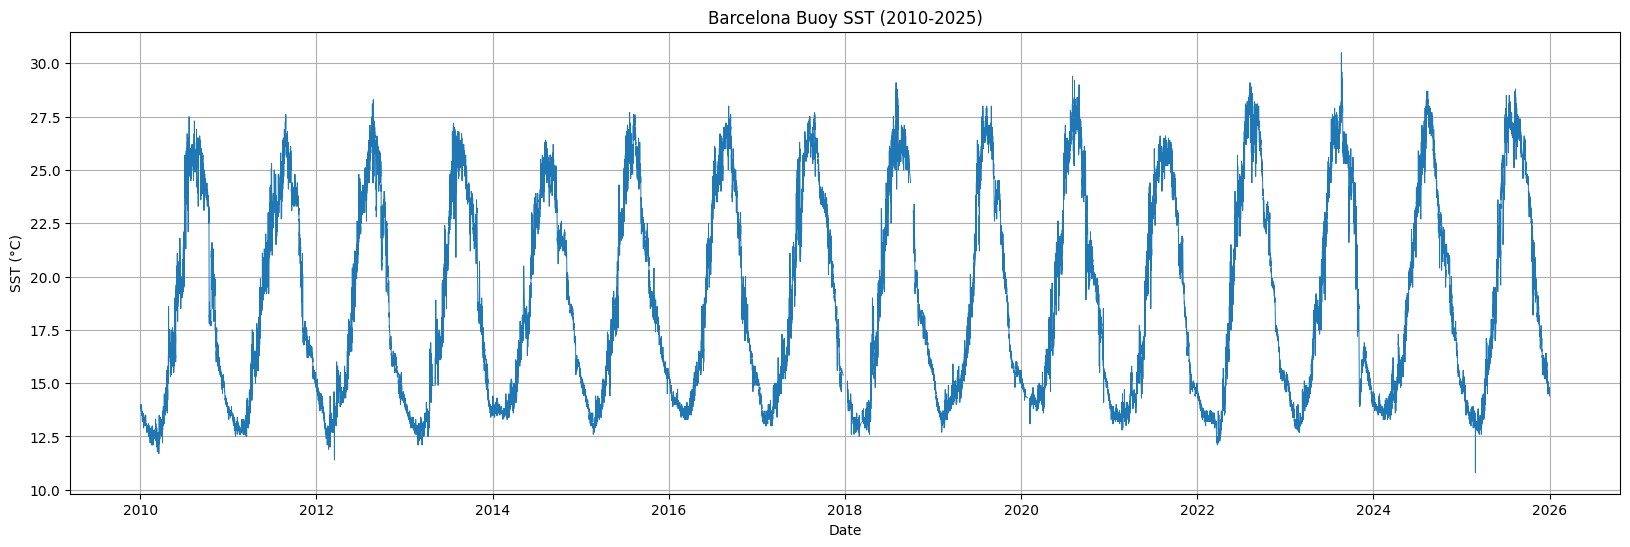

In [22]:
# ============================================================
# SST FULL TIMESERIES
# ============================================================
plt.figure(figsize=(20, 6))
plt.plot(
    df.index,
    df['sst'],
    linewidth=0.7
)
plt.title('Barcelona Buoy SST (2010-2025)')
plt.xlabel('Date')
plt.ylabel('SST (°C)')
plt.grid(True)
plt.show()

In [23]:
# ============================================================
# SST BASIC STATISTICS
# ============================================================

display(df['sst'].describe())

count    139142.000000
mean         18.905444
std           4.789294
min          10.800000
25%          14.400000
50%          17.800000
75%          23.600000
max          30.500000
Name: sst, dtype: float64

In [24]:
# ============================================================
# DETECT POSSIBLE SST SPIKES
# ============================================================

# Cambio horario absoluto
sst_diff = df['sst'].diff().abs()

# Detectar saltos sospechosos
spikes = df[sst_diff > 1.5]

print(f"Possible spikes detected: {len(spikes)}")

display(spikes[['sst']].head(20))

Possible spikes detected: 14


,sst
2010-08-28 05:00:00,23.7
2012-03-15 08:00:00,11.4
2013-05-08 17:00:00,17.2
2015-06-04 09:00:00,20.2
2016-11-11 20:00:00,19.0
2018-05-31 15:00:00,23.2
2018-08-03 08:00:00,26.4
2020-05-26 16:00:00,21.6
2020-08-27 09:00:00,27.8
2020-12-08 14:00:00,14.1


In [25]:
# ============================================================
# REMOVE ANOMALOUS MIN SST VALUE
# ============================================================

df.loc[df['sst'] == df['sst'].min(), 'sst'] = np.nan

print("Anomalous minimum SST removed.")

Anomalous minimum SST removed.


In [26]:
# Reinterpolar pequeño gap
df['sst'] = df['sst'].interpolate(

    method='time',
    limit=24

)

In [27]:
# ============================================================
# RENAME REMAINING IMPORTANT COLUMNS
# ============================================================

df = df.rename(columns={

    'direcc_media_de_proced0n,90e': 'wave_direction',

    'direccion_media_en_el_pico_espectral0n,90e':
        'wave_peak_direction',

    'altura_signif_de_cruce_por_cero_h1_3m':
        'wave_height_h13',

    'altura_máxima_del_oleajem':
        'wave_max_height',

    'periodo_de_la_ola_maximas':
        'wave_max_period',

    'dispersión_angular_en_el_pico_de_energía_espectralgrados':
        'wave_angular_spread'

})

print("Remaining columns renamed successfully.")

Remaining columns renamed successfully.


In [28]:
# ============================================================
# SELECT RELEVANT COLUMNS
# ============================================================

selected_columns = [

    'sst',
    'sst_original',

    'wave_height',
    'wave_height_h13',

    'wave_period_mean',
    'wave_period_tm02',

    'wave_peak_period',
    'wave_max_period',

    'wave_direction',
    'wave_peak_direction',

    'wave_angular_spread'

]

df = df[selected_columns]

print("Relevant columns selected.")

display(df.head())

Relevant columns selected.


,sst,sst_original,wave_height,wave_height_h13,wave_period_mean,wave_period_tm02,wave_peak_period,wave_max_period,wave_direction,wave_peak_direction,wave_angular_spread
2010-01-01 00:00:00,14.0,14.0,2.05,1.84,5.55,5.14,6.65,6.78,210.0,210.0,20.0
2010-01-01 01:00:00,14.0,14.0,1.88,1.78,5.53,5.06,7.13,7.00,213.0,205.0,20.0
2010-01-01 02:00:00,14.0,14.0,1.95,1.84,5.76,5.02,7.13,7.67,217.0,219.0,29.0
2010-01-01 03:00:00,14.0,14.0,2.24,2.08,6.10,5.53,7.68,8.55,214.0,213.0,24.0
2010-01-01 04:00:00,14.0,14.0,2.62,2.37,6.46,5.85,7.67,8.19,214.0,212.0,23.0


In [29]:
# ============================================================
# BASIC SST QUALITY CHECK
# ============================================================

print("\nSST STATISTICS")
display(df['sst'].describe())

print("\nSST MIN/MAX")
print(f"Min SST: {df['sst'].min():.2f} °C")
print(f"Max SST: {df['sst'].max():.2f} °C")


SST STATISTICS


count    139262.000000
mean         18.903309
std           4.789232
min          11.400000
25%          14.400000
50%          17.800000
75%          23.600000
max          30.500000
Name: sst, dtype: float64


SST MIN/MAX
Min SST: 11.40 °C
Max SST: 30.50 °C


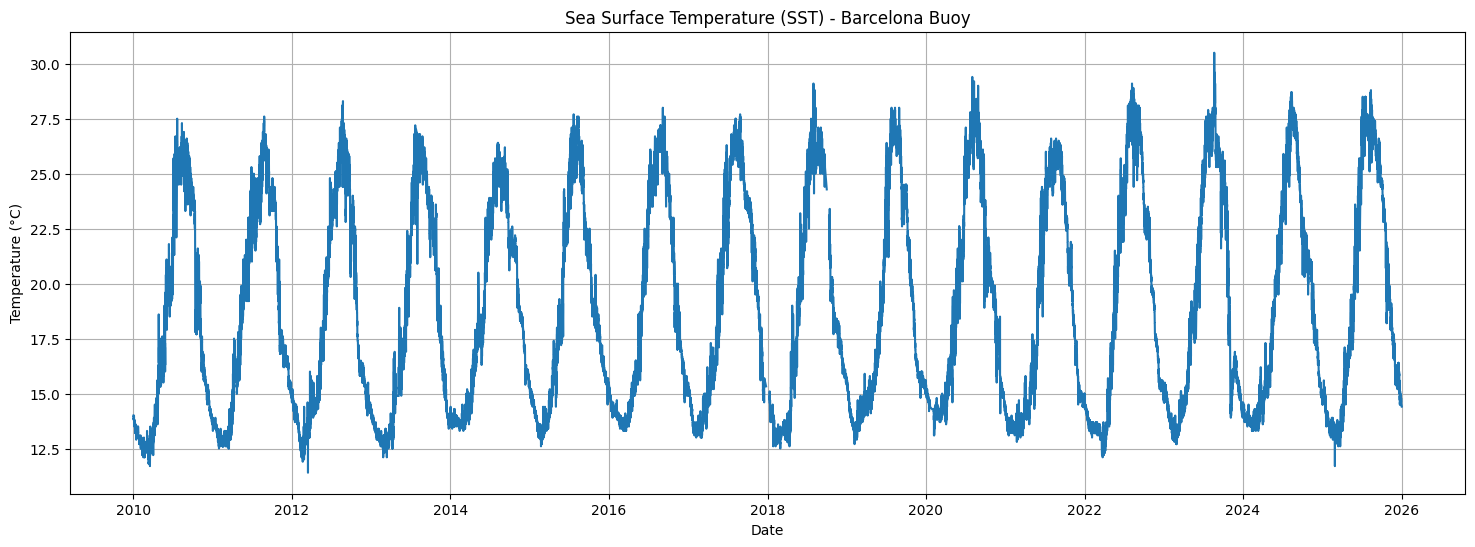

In [30]:
# ============================================================
# SST TIME SERIES PLOT
# ============================================================

plt.figure(figsize=(18, 6))

plt.plot(df.index, df['sst'])

plt.title('Sea Surface Temperature (SST) - Barcelona Buoy')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')

plt.grid(True)

plt.show()

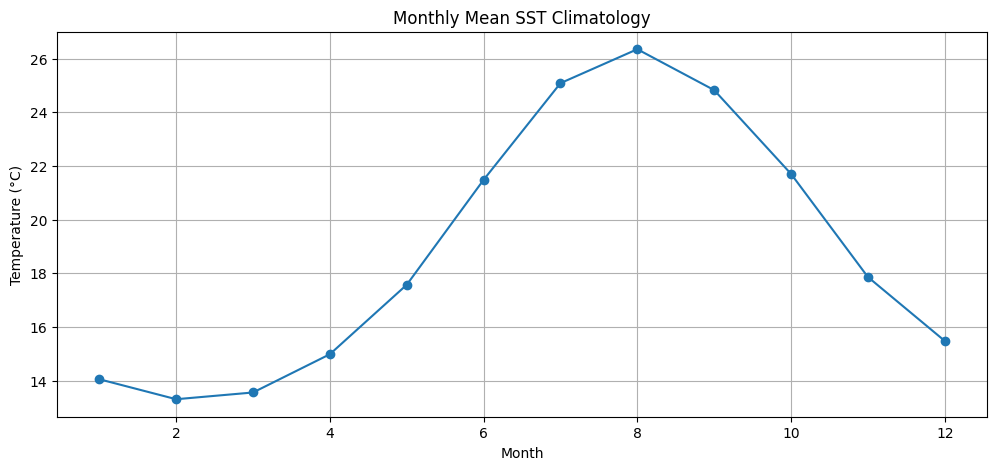

In [31]:
# ============================================================
# MONTHLY SST CLIMATOLOGY
# ============================================================

monthly_sst = df['sst'].groupby(df.index.month).mean()

plt.figure(figsize=(12, 5))

monthly_sst.plot(marker='o')

plt.title('Monthly Mean SST Climatology')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')

plt.grid(True)

plt.show()

In [32]:
# ============================================================
# TEMPORAL CONTINUITY CHECK
# ============================================================

# Diferencias temporales
time_diff = df.index.to_series().diff()

print(time_diff.value_counts().head(10))

0 days 01:00:00    140255
Name: count, dtype: int64


In [33]:
# ============================================================
# CREATE BASIC SST FEATURES
# ============================================================

# Rolling means
df['sst_roll_6h'] = df['sst'].rolling(6).mean()

df['sst_roll_24h'] = df['sst'].rolling(24).mean()

# SST changes
df['sst_delta_3h'] = df['sst'].diff(3)

df['sst_delta_24h'] = df['sst'].diff(24)

print("Basic SST features created.")

Basic SST features created.


In [34]:
# ============================================================
# FINAL INSPECTION
# ============================================================

display(df.head(10))

print(df.info())

,sst,sst_original,wave_height,wave_height_h13,wave_period_mean,wave_period_tm02,wave_peak_period,wave_max_period,wave_direction,wave_peak_direction,wave_angular_spread,sst_roll_6h,sst_roll_24h,sst_delta_3h,sst_delta_24h
2010-01-01 00:00:00,14.0,14.0,2.05,1.84,5.55,5.14,6.65,6.78,210.0,210.0,20.0,NaN,NaN,NaN,NaN
2010-01-01 01:00:00,14.0,14.0,1.88,1.78,5.53,5.06,7.13,7.00,213.0,205.0,20.0,NaN,NaN,NaN,NaN
2010-01-01 02:00:00,14.0,14.0,1.95,1.84,5.76,5.02,7.13,7.67,217.0,219.0,29.0,NaN,NaN,NaN,NaN
2010-01-01 03:00:00,14.0,14.0,2.24,2.08,6.10,5.53,7.68,8.55,214.0,213.0,24.0,NaN,NaN,0.0,NaN
2010-01-01 04:00:00,14.0,14.0,2.62,2.37,6.46,5.85,7.67,8.19,214.0,212.0,23.0,NaN,NaN,0.0,NaN
2010-01-01 05:00:00,14.0,14.0,2.62,2.49,6.65,6.00,7.68,8.63,212.0,214.0,23.0,14.000000,NaN,0.0,NaN
2010-01-01 06:00:00,13.9,13.9,2.44,2.29,6.91,6.04,8.32,9.05,213.0,208.0,18.0,13.983333,NaN,-0.1,NaN
2010-01-01 07:00:00,14.0,14.0,2.06,1.95,6.50,5.70,8.32,8.03,216.0,220.0,24.0,13.983333,NaN,0.0,NaN
2010-01-01 08:00:00,13.9,13.9,2.36,2.28,7.32,6.23,8.66,8.28,216.0,216.0,17.0,13.966667,NaN,-0.1,NaN
2010-01-01 09:00:00,13.9,13.9,2.04,1.95,6.31,5.66,8.32,8.42,215.0,211.0,24.0,13.950000,NaN,0.0,NaN


<class 'pandas.DataFrame'>
DatetimeIndex: 140256 entries, 2010-01-01 00:00:00 to 2025-12-31 23:00:00
Freq: h
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   sst                  139262 non-null  float64
 1   sst_original         136660 non-null  float64
 2   wave_height          136370 non-null  float64
 3   wave_height_h13      136370 non-null  float64
 4   wave_period_mean     136370 non-null  float64
 5   wave_period_tm02     136100 non-null  float64
 6   wave_peak_period     136370 non-null  float64
 7   wave_max_period      129486 non-null  float64
 8   wave_direction       135613 non-null  float64
 9   wave_peak_direction  128729 non-null  float64
 10  wave_angular_spread  128729 non-null  float64
 11  sst_roll_6h          139232 non-null  float64
 12  sst_roll_24h         139124 non-null  float64
 13  sst_delta_3h         139244 non-null  float64
 14  sst_delta_24h        139118 non-null 

In [35]:
# ============================================================
# SAVE PROCESSED DATASET
# ============================================================

output_file = (
    PROCESSED_DATA_PATH /
    "barcelona_buoy_processed.parquet"
)

df.to_parquet(output_file)

print("Processed dataset saved successfully.")
print(output_file)

Processed dataset saved successfully.
/Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/03_Especialitzacio/Project/thermal-wind-prediction/data/processed/barcelona_buoy_processed.parquet


In [36]:
# ============================================================
# OPTIONAL CSV EXPORT
# ============================================================

csv_output = (
    PROCESSED_DATA_PATH /
    "barcelona_buoy_processed.csv"
)

df.to_csv(csv_output)

print("CSV export completed.")

CSV export completed.


In [37]:
# ============================================
# EXPORT BUOY SAMPLE + INFO
# ============================================

from pathlib import Path
import pandas as pd

# --------------------------------------------
# OUTPUT DIRECTORY
# --------------------------------------------

output_dir = Path(
    "/Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/03_Especialitzacio/Project/thermal-wind-prediction/data/samples"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

# ============================================
# EXPORT FIRST 10 ROWS
# ============================================

buoy_sample = df.head(10)

sample_path = output_dir / "buoy_sample_10rows.csv"

buoy_sample.to_csv(
    sample_path,
    index=True
)

print("Sample exported:")
print(sample_path)

# ============================================
# EXPORT DTYPES
# ============================================

dtypes_df = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str)
})

dtypes_path = output_dir / "buoy_dtypes.csv"

dtypes_df.to_csv(
    dtypes_path,
    index=False
)

print("\nDtypes exported:")
print(dtypes_path)

# ============================================
# EXPORT COLUMN LIST
# ============================================

columns_df = pd.DataFrame({
    "columns": df.columns
})

columns_path = output_dir / "buoy_columns.csv"

columns_df.to_csv(
    columns_path,
    index=False
)

print("\nColumns exported:")
print(columns_path)

# ============================================
# BASIC INFO
# ============================================

print("\nDataset shape:")
print(df.shape)

print("\nDate range:")

try:
    print(df.index.min())
    print(df.index.max())
except:
    print("No datetime index detected")

# ============================================
# OPTIONAL PREVIEW
# ============================================

display(buoy_sample)

Sample exported:
/Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/03_Especialitzacio/Project/thermal-wind-prediction/data/samples/buoy_sample_10rows.csv

Dtypes exported:
/Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/03_Especialitzacio/Project/thermal-wind-prediction/data/samples/buoy_dtypes.csv

Columns exported:
/Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/03_Especialitzacio/Project/thermal-wind-prediction/data/samples/buoy_columns.csv

Dataset shape:
(140256, 15)

Date range:
2010-01-01 00:00:00
2025-12-31 23:00:00


,sst,sst_original,wave_height,wave_height_h13,wave_period_mean,wave_period_tm02,wave_peak_period,wave_max_period,wave_direction,wave_peak_direction,wave_angular_spread,sst_roll_6h,sst_roll_24h,sst_delta_3h,sst_delta_24h
2010-01-01 00:00:00,14.0,14.0,2.05,1.84,5.55,5.14,6.65,6.78,210.0,210.0,20.0,NaN,NaN,NaN,NaN
2010-01-01 01:00:00,14.0,14.0,1.88,1.78,5.53,5.06,7.13,7.00,213.0,205.0,20.0,NaN,NaN,NaN,NaN
2010-01-01 02:00:00,14.0,14.0,1.95,1.84,5.76,5.02,7.13,7.67,217.0,219.0,29.0,NaN,NaN,NaN,NaN
2010-01-01 03:00:00,14.0,14.0,2.24,2.08,6.10,5.53,7.68,8.55,214.0,213.0,24.0,NaN,NaN,0.0,NaN
2010-01-01 04:00:00,14.0,14.0,2.62,2.37,6.46,5.85,7.67,8.19,214.0,212.0,23.0,NaN,NaN,0.0,NaN
2010-01-01 05:00:00,14.0,14.0,2.62,2.49,6.65,6.00,7.68,8.63,212.0,214.0,23.0,14.000000,NaN,0.0,NaN
2010-01-01 06:00:00,13.9,13.9,2.44,2.29,6.91,6.04,8.32,9.05,213.0,208.0,18.0,13.983333,NaN,-0.1,NaN
2010-01-01 07:00:00,14.0,14.0,2.06,1.95,6.50,5.70,8.32,8.03,216.0,220.0,24.0,13.983333,NaN,0.0,NaN
2010-01-01 08:00:00,13.9,13.9,2.36,2.28,7.32,6.23,8.66,8.28,216.0,216.0,17.0,13.966667,NaN,-0.1,NaN
2010-01-01 09:00:00,13.9,13.9,2.04,1.95,6.31,5.66,8.32,8.42,215.0,211.0,24.0,13.950000,NaN,0.0,NaN
